## Overview

This notebook is a direct implementation of tensorflow's [tutorial on DP-SGD](https://www.tensorflow.org/responsible_ai/privacy/tutorials/classification_privacy) adjusted on the Logistic Regression model I am using.

[Differential privacy](https://en.wikipedia.org/wiki/Differential_privacy) (DP) is a framework for measuring the privacy guarantees provided by an algorithm. Through the lens of differential privacy, you can design machine learning algorithms that responsibly train models on private data. Learning with differential privacy provides measurable guarantees of privacy, helping to mitigate the risk of exposing sensitive training data in machine learning. Intuitively, a model trained with differential privacy should not be affected by any single training example, or small set of training examples, in its data set. This helps mitigate the risk of exposing sensitive training data in ML.

The basic idea of this approach, called differentially private stochastic gradient descent (DP-SGD), is to modify the gradients
used in stochastic gradient descent (SGD), which lies at the core of almost all deep learning algorithms. Models trained with DP-SGD provide provable differential privacy guarantees for their input data. There are two modifications made to the vanilla SGD algorithm:

1. First, the sensitivity of each gradient needs to be bounded. In other words, you need to limit how much each individual training point sampled in a minibatch can influence gradient computations and the resulting updates applied to model parameters. This can be done by *clipping* each gradient computed on each training point.
2. *Random noise* is sampled and added to the clipped gradients to make it statistically impossible to know whether or not a particular data point was included in the training dataset by comparing the updates SGD applies when it operates with or without this particular data point in the training dataset.

This tutorial uses [tf.keras](https://www.tensorflow.org/guide/keras) to train a convolutional neural network (CNN) to recognize handwritten digits with the DP-SGD optimizer provided by the TensorFlow Privacy library. TensorFlow Privacy provides code that wraps an existing TensorFlow optimizer to create a variant that implements DP-SGD.

## Setup

Begin by importing the necessary libraries:

In [2]:
import tensorflow as tf
import numpy as np
import tensorflow_privacy
#from tensorflow_privacy.privacy.analysis import compute_dp_sgd_privacy
from tensorflow_privacy.privacy.analysis import compute_dp_sgd_privacy_lib
from dp_accounting.rdp import RdpAccountant
from dp_accounting.dp_event import PoissonSampledDpEvent, GaussianDpEvent
print("Done importing...")

Done importing...


## Load and pre-process the dataset

Load the [MNIST](http://yann.lecun.com/exdb/mnist/) dataset and prepare the data for training.

In [3]:
def load_dataset(n):
    train, test = tf.keras.datasets.mnist.load_data()
    train_data, train_labels = train
    test_data, test_labels = test
    
    idx = np.random.choice(len(train_data), size=n, replace=False)
    train_data = train_data[idx]
    train_labels = train_labels[idx]
    
    train_data = np.array(train_data, dtype=np.float32) / 255
    test_data = np.array(test_data, dtype=np.float32) / 255
    
    # Reshape to vectors of size 28*28 = 784
    train_data = train_data.reshape(train_data.shape[0], 28 * 28)
    test_data = test_data.reshape(test_data.shape[0], 28 * 28)
    
    
    train_labels = np.array(train_labels, dtype=np.int32)
    test_labels = np.array(test_labels, dtype=np.int32)
    
    train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
    test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)
    
    num_classes = 10
    means = np.zeros((num_classes, train_data.shape[1]), dtype=np.float32)
    
    # Convert one-hot labels back to class indices
    train_labels_int = np.argmax(train_labels, axis=1)
    
    for c in range(num_classes):
        class_samples = train_data[train_labels_int == c]
        means[c] = np.mean(class_samples, axis=0)
        
    assert train_data.min() == 0.
    assert train_data.max() == 1.
    assert test_data.min() == 0.
    assert test_data.max() == 1.

    return train_data, train_labels, test_data, test_labels, means

train_data, train_labels, test_data, test_labels, means = load_dataset(2000)
print("Train data shape: ", train_data.shape)
print("Test data shape: ", test_data.shape)
print("Means shape:", means.shape)  # (10, 784)

Train data shape:  (2000, 784)
Test data shape:  (10000, 784)
Means shape: (10, 784)


## Define the hyperparameters
Set learning model hyperparamter values. 

DP-SGD has three privacy-specific hyperparameters and one existing hyperamater that you must tune:

1. `l2_norm_clip` (float) - The maximum Euclidean (L2) norm of each gradient that is applied to update model parameters. This hyperparameter is used to bound the optimizer's sensitivity to individual training points. 
2. `noise_multiplier` (float) - The amount of noise sampled and added to gradients during training. Generally, more noise results in better privacy (often, but not necessarily, at the expense of lower utility).
3.   `microbatches` (int) - Each batch of data is split in smaller units called microbatches. By default, each microbatch should contain a single training example. This allows us to clip gradients on a per-example basis rather than after they have been averaged across the minibatch. This in turn decreases the (negative) effect of clipping on signal found in the gradient and typically maximizes utility. However, computational overhead can be reduced by increasing the size of microbatches to include more than one training examples. The average gradient across these multiple training examples is then clipped. The total number of examples consumed in a batch, i.e., one step of gradient descent, remains the same. The number of microbatches should evenly divide the batch size. 
4. `learning_rate` (float) - This hyperparameter already exists in vanilla SGD. The higher the learning rate, the more each update matters. If the updates are noisy (such as when the additive noise is large compared to the clipping threshold), a low learning rate may help the training procedure converge. 

Use the hyperparameter values below to obtain a reasonably accurate model (95% test accuracy):

In [4]:
epochs = 3
batch_size = 250
l2_norm_clip = 1.5
noise_multiplier = 1.3
num_microbatches = 250
learning_rate = 0.25

if batch_size % num_microbatches != 0:
  raise ValueError('Batch size should be an integer multiple of the number of microbatches')

## Build the model
Input layer of dimension $d=28*28=784$ and a linear layer which outputs the logits.

In [5]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),   # or (28*28,)
        tf.keras.layers.Dense(10)              # logits, no activation
    ])
    return model
model = build_model()

Define the optimizer and loss function for the learning model. Compute the loss as a vector of losses per-example rather than as the mean over a minibatch to support gradient manipulation over each training point. 

In [6]:
optimizer = tensorflow_privacy.DPKerasSGDOptimizer(
    l2_norm_clip=l2_norm_clip,
    noise_multiplier=noise_multiplier,
    num_microbatches=num_microbatches,
    learning_rate=learning_rate)

loss = tf.keras.losses.CategoricalCrossentropy(
    from_logits=True, reduction=tf.losses.Reduction.NONE)

## Train the model


In [7]:
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

model.fit(train_data, train_labels,
          epochs=epochs,
          validation_data=(test_data, test_labels),
          batch_size=batch_size)

Epoch 1/3
8/8 [==============================] - 1s 68ms/step - loss: 2.2512 - accuracy: 0.1640 - val_loss: 2.0633 - val_accuracy: 0.3154
Epoch 2/3
8/8 [==============================] - 0s 38ms/step - loss: 1.9357 - accuracy: 0.4245 - val_loss: 1.7797 - val_accuracy: 0.5364
Epoch 3/3
8/8 [==============================] - 0s 37ms/step - loss: 1.6831 - accuracy: 0.5780 - val_loss: 1.5530 - val_accuracy: 0.6353


## Measure the differential privacy guarantee

Perform a privacy analysis to measure the DP guarantee achieved by a training algorithm. Knowing the level of DP achieved enables the objective comparison of two training runs to determine which of the two is more privacy-preserving. At a high level, the privacy analysis measures how much a potential adversary can improve their guess about properties of any individual training point by observing the outcome of the training procedure (e.g., model updates and parameters). 

This guarantee is sometimes referred to as the **privacy budget**. A lower privacy budget bounds more tightly an adversary's ability to improve their guess. This ensures a stronger privacy guarantee. Intuitively, this is because it is harder for a single training point to affect the outcome of learning: for instance, the information contained in the training point cannot be memorized by the ML algorithm and the privacy of the individual who contributed this training point to the dataset is preserved.

In this tutorial, the privacy analysis is performed in the framework of Rényi Differential Privacy (RDP), which is a relaxation of pure DP based on [this paper](https://arxiv.org/abs/1702.07476) that is particularly well suited for DP-SGD.

Two metrics are used to express the DP guarantee of an ML algorithm:

1.   Delta ($\delta$) - Bounds the probability of the privacy guarantee not holding. A rule of thumb is to set it to be less than the inverse of the size of the training dataset. In this tutorial, it is set to **10^-5** as the MNIST dataset has 60,000 training points.
2.   Epsilon ($\epsilon$) - This is the privacy budget. It measures the strength of the privacy guarantee by bounding how much the probability of a particular model output can vary by including (or excluding) a single training point. A smaller value for $\epsilon$ implies a better privacy guarantee. However, the $\epsilon$ value is only an upper bound and a large value could still mean good privacy in practice.

Tensorflow Privacy provides a tool, `compute_dp_sgd_privacy`, to compute the value of $\epsilon$ given a fixed value of $\delta$ and the following hyperparameters from the training process:

1.   The total number of points in the training data, `n`.
2. The `batch_size`.
3.   The `noise_multiplier`.
4. The number of `epochs` of training.


In [8]:
def compute_epsilon(n, batch_size, noise_multiplier, epochs, delta):
    steps = (n // batch_size) * epochs

    # Build the DP-SGD event
    sample_rate = batch_size / n
    accountant = RdpAccountant()
    event = PoissonSampledDpEvent(
        sampling_probability=sample_rate,
        event=GaussianDpEvent(noise_multiplier)
    )

    # Accumulate privacy events
    accountant.compose(event, count=steps)

    # Compute epsilon
    return accountant.get_epsilon(delta)


In [9]:
epsilon = compute_epsilon(
    n=train_data.shape[0],
    batch_size=batch_size,
    noise_multiplier=noise_multiplier,
    epochs=epochs,
    delta=1e-5
)


print("Epsilon =", epsilon)


Epsilon = 3.339889050569681


In [11]:
compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy(n=train_data.shape[0],
                                 
                                                  batch_size=batch_size,
                                              noise_multiplier=noise_multiplier,
                                              epochs=epochs,
                                              delta=1e-5)

(3.372610819732178, 5.0)

In [12]:
compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy_statement(number_of_examples=train_data.shape[0],
                                              batch_size=batch_size,
                                              noise_multiplier=noise_multiplier,
                                              num_epochs=epochs,
                                              delta=1e-5)

'DP-SGD performed over 2000 examples with 250 examples per iteration, noise\nmultiplier 1.3 for 3 epochs with microbatching, and no bound on number of\nexamples per user.\n\nThis privacy guarantee protects the release of all model checkpoints in addition\nto the final model.\n\nExample-level DP with add-or-remove-one adjacency at delta = 1e-05 computed with\nRDP accounting:\n    Epsilon with each example occurring once per epoch:        15.311\n    Epsilon assuming Poisson sampling (*):                     12.823\n\nNo user-level privacy guarantee is possible without a bound on the number of\nexamples per user.\n\n(*) Poisson sampling is not usually done in training pipelines, but assuming\nthat the data was randomly shuffled, it is believed that the actual epsilon\nshould be closer to this value than the conservative assumption of an arbitrary\ndata order.\n'

# Experiments for different $\epsilon$ values
Next, we need to find the $\sigma$ value that yields the target $\epsilon$. Since $\epsilon(\sigma)$ is a monotonically decreasing function, we implement a binary search to find the corresponding $\sigma$.

## Setup

* **learning rate**: 0.25
* **epochs**: 1st senario with 3 epochs and 2nd with 100 epochs. At the compartison with output perturbation we had 10 epochs.
* **batch size**: 250
* **microbatches**: 250
* **delta**: $10^{-5}$
* **training dataset size** $n$: 2000

In [13]:
def find_sigma_for_target_epsilon(target_eps, steps, delta,
                                 sigma_min=0.1, sigma_max=100,
                                 tol=0.01, max_iter=40):

    for _ in range(max_iter):
        

        sigma_mid = (sigma_min + sigma_max)/2
        eps_mid = compute_epsilon(n=train_data.shape[0], batch_size=batch_size, noise_multiplier=sigma_mid,
                                  epochs=epochs, delta=1e-5
                                 )
        #print(f"eps_mid = {eps_mid}, sigma_min = {sigma_min}, sigma_max = {sigma_max}")
        if abs(eps_mid - target_eps) < tol:
            return sigma_mid

        if eps_mid > target_eps:
            sigma_min = sigma_mid
        else:
            sigma_max = sigma_mid

    return sigma_mid

sigma = find_sigma_for_target_epsilon(0.1, epochs, 1e-5)
print(sigma)

21.953125


In [14]:
def reconstruction_tf(
    model,
    label,
    class_mean=None,
    test_data=None,
    test_labels=None,
    H=28,
    W=28,
    step_size=0.1,
    tv_weight=0.01,
    init_mode="zeros",
    show_cost=False,
    verbose=False,
    thres=1e-5,
    max_iters=10000
):
    """
    TensorFlow MI-Face reconstruction attack
    """

    if verbose:
        print(f"Beginning reconstruction attack, target label = {label}")

    # -----------------------
    # Test accuracy 
    # -----------------------
    acc = -1.0
    if test_data is not None and test_labels is not None:
        logits = model(test_data, training=False)
        preds = tf.argmax(logits, axis=1)
        acc = tf.reduce_mean(
            tf.cast(preds == tf.argmax(test_labels, axis=1), tf.float32)
        ).numpy()

        if verbose:
            print(f"Test accuracy: {acc:.4f}")

    # -----------------------
    # Initialize image
    # -----------------------
    if init_mode == "zeros":
        x_img = tf.Variable(tf.zeros([1, H * W], dtype=tf.float32))
    elif init_mode == "ones":
        x_img = tf.Variable(tf.ones([1, H * W], dtype=tf.float32))
    elif init_mode == "noise":
        x_img = tf.Variable(tf.random.normal([1, H * W], stddev=0.1))
    elif init_mode == "weights":
        w = model.trainable_variables[0][:, label]
        x_img = tf.Variable(tf.reshape(w, [1, H * W]))
    else:
        x_img = tf.Variable(tf.zeros([1, H * W], dtype=tf.float32))

    optimizer = tf.keras.optimizers.SGD(learning_rate=step_size)

    best_img = None
    best_prob = -1.0
    loss_list = []

    iters = 0

    # -----------------------
    # Optimization loop
    # -----------------------
    while True:
        iters += 1
        x_prev = tf.identity(x_img)

        with tf.GradientTape() as tape:
            logits = model(x_img, training=False)
            probs = tf.nn.softmax(logits, axis=1)

            loss = 1.0 - probs[0, label] 

        grads = tape.gradient(loss, [x_img])
        optimizer.apply_gradients(zip(grads, [x_img]))

        loss_list.append(loss.numpy())

        # -----------------------
        # Track best reconstruction
        # -----------------------
        p = probs[0, label].numpy()
        if p > best_prob:
            best_prob = p
            best_img = tf.identity(x_img)

        # -----------------------
        # Convergence check
        # -----------------------
        num = tf.norm(x_prev - x_img)
        denom = tf.norm(x_img) + 1e-12
        thres_val = (num / denom).numpy()

        if verbose and iters % 1000 == 0:
            print(f"Iter {iters}, threshold={thres_val:.6e}, prob={p:.4f}")

        if thres_val < thres or iters >= max_iters:
            break


    if verbose:
        print(f"Finished in {iters} iterations")

    return best_img, best_prob, loss_list, acc


In [15]:
import math

# Helper function
def angle_between(u, v, eps=1e-7):
    u = np.array(u, dtype=np.float64)
    v = np.array(v, dtype=np.float64)

    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)

    if norm_u < eps and norm_v < eps:
        return 0.0, 0.0
    elif norm_u < eps or norm_v < eps:
        return np.pi / 2, 90.0

    cos_theta = np.dot(u, v) / (norm_u * norm_v)

    # Numerical safety: clip before arccos
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    angle_rad = np.arccos(cos_theta)
    angle_deg = np.degrees(angle_rad)
    return angle_rad, angle_deg

def perform_experiment(epsilon, delta=1e-5, learning_rate=0.25, num_microbatches=250, l2_norm_clip=1.5, epochs=3, batch_size=250):
    '''
    Performs an expiriment for a specific privacy budget.
    Calculates and returns the accuracy and the angle of recostruction.
    '''
    print(f'Performing experiment for epsilon = {epsilon}')
    model = build_model()
    noise_multiplier = find_sigma_for_target_epsilon(epsilon, epochs, delta)
    optimizer = tensorflow_privacy.DPKerasSGDOptimizer(l2_norm_clip=l2_norm_clip,
                                                       noise_multiplier=noise_multiplier,
                                                       num_microbatches=num_microbatches, 
                                                       learning_rate=learning_rate
                                                      )

    loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True, 
                                                   reduction=tf.losses.Reduction.NONE
                                                  )
    # Train the model
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    model.fit(train_data, train_labels,
              epochs=epochs,
              validation_data=(test_data, test_labels),
              batch_size=batch_size)

    # Calculate the accuracy on validation set.
    _, val_acc = model.evaluate(test_data, test_labels, batch_size=batch_size, verbose=0)
    
    # Calculate the angle.
    cum_angle = 0
    for label in range(10):
        rec_img, best_conf, loss_list, _ = reconstruction_tf(model, label, H=28, W=28,
                                                                    init_mode="weights", thres=1e-4, verbose=False
                                                                    )

        rec_img = np.array(rec_img)[0,:]
        vmin = np.min(rec_img)
        vmax = np.max(rec_img)
        rec_img = (rec_img - vmin)/(vmax - vmin)

        vmin = np.min(means[label])
        vmax = np.max(means[label])
        means[label] = (means[label] - vmin)/(vmax - vmin)
        
        angle, _ = angle_between(rec_img, means[label])
        
        cum_angle += math.sin(angle)
        
    return val_acc, cum_angle/10

    
acc, angle = perform_experiment(10)
print("Accuracy: ", acc)
print("Angle: ", angle)

Performing experiment for epsilon = 10
Epoch 1/3
8/8 [==============================] - 1s 56ms/step - loss: 2.2651 - accuracy: 0.1410 - val_loss: 2.0811 - val_accuracy: 0.2984
Epoch 2/3
8/8 [==============================] - 0s 47ms/step - loss: 1.9397 - accuracy: 0.4460 - val_loss: 1.7906 - val_accuracy: 0.5611
Epoch 3/3
8/8 [==============================] - 0s 37ms/step - loss: 1.6766 - accuracy: 0.6110 - val_loss: 1.5523 - val_accuracy: 0.6323
Accuracy:  0.6323000192642212
Angle:  0.8438101157988551


Performing experiment for epsilon = 0.01
Epoch 1/15
8/8 [==============================] - 1s 41ms/step - loss: 3.4524 - accuracy: 0.1050 - val_loss: 5.0618 - val_accuracy: 0.1271
Epoch 2/15
8/8 [==============================] - 0s 31ms/step - loss: 5.7078 - accuracy: 0.1150 - val_loss: 6.3074 - val_accuracy: 0.1309
Epoch 3/15
8/8 [==============================] - 0s 29ms/step - loss: 6.3698 - accuracy: 0.1375 - val_loss: 7.1764 - val_accuracy: 0.1352
Epoch 4/15
8/8 [==============================] - 0s 33ms/step - loss: 7.7039 - accuracy: 0.1430 - val_loss: 9.1948 - val_accuracy: 0.1304
Epoch 5/15
8/8 [==============================] - 0s 27ms/step - loss: 9.5612 - accuracy: 0.1580 - val_loss: 10.4776 - val_accuracy: 0.1297
Epoch 6/15
8/8 [==============================] - 0s 28ms/step - loss: 10.2828 - accuracy: 0.1480 - val_loss: 10.7522 - val_accuracy: 0.1250
Epoch 7/15
8/8 [==============================] - 0s 30ms/step - loss: 10.8465 - accuracy: 0.1610 - val_loss: 11.4485 - va

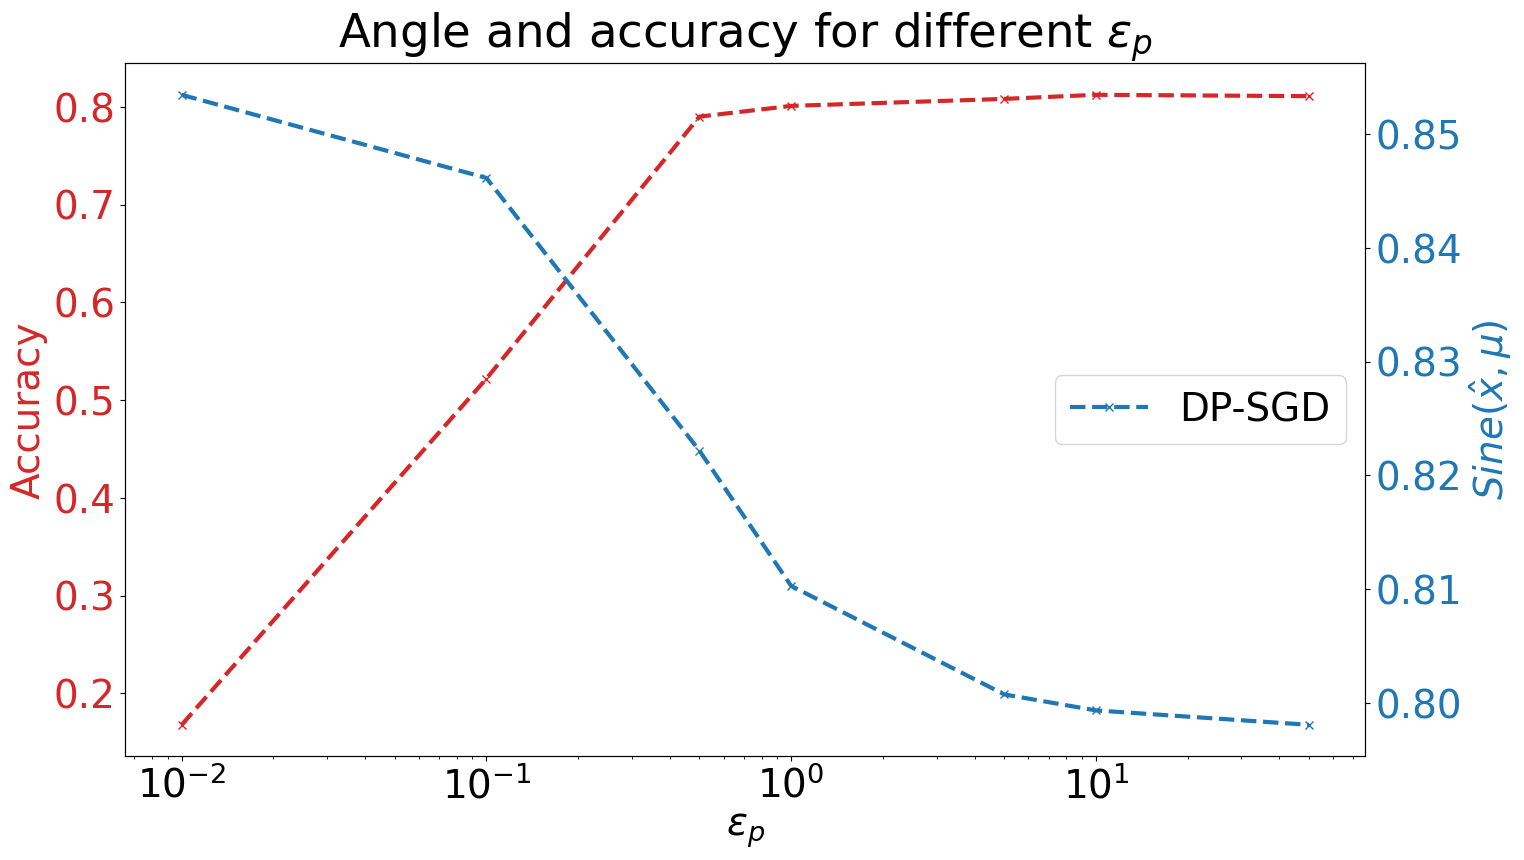

In [36]:
import matplotlib.pyplot as plt

#eps_arr = np.load('./data/epsilon_arr_gaussian_delta1e-5.npy')
eps_arr = [0.01, 0.1, 0.5, 1, 5, 10, 50]

acc_dpsgd, angles_dpsgd = [], []
iters = 10

for eps in eps_arr:
    acc, angle = 0, 0
    for _ in range(iters):
        acc_tmp, angle_tmp = perform_experiment(eps, epochs=15)
        acc += acc_tmp
        angle += angle_tmp
    acc_dpsgd.append(acc/iters)
    angles_dpsgd.append(angle/iters)


# Plot the results.
plt.rcParams.update({'font.size': 28})
fig, ax1 = plt.subplots()
fig.set_size_inches(16, 9)
color = 'tab:red'
ax1.set_xlabel(r'$\epsilon_p$')
ax1.set_ylabel('Accuracy', color=color)
ax1.semilogx(eps_arr, acc_dpsgd, color=color, linestyle='--', marker='x', linewidth=3, label='DP-SGD')
#ax1.plot(eps_arr, acc_output, color=color, linestyle='-.', marker='o',linewidth=3, label='output')
#ax1.plot(eps_arr, acc_non_private, color=color, linestyle='-',linewidth=3, label='non private')
ax1.tick_params(axis='y', labelcolor=color)
        
ax2 = ax1.twinx()
        
color = 'tab:blue'
ax2.set_ylabel(r'$Sine(\hat{x}, \mu)$', color=color)
ax2.semilogx(eps_arr, angles_dpsgd, color=color, linestyle='--', linewidth=3, marker='x', label='DP-SGD')
#ax2.plot(eps_arr, angles_output, color=color, linestyle='-.', linewidth=3, marker='o', label='output')
#ax2.plot(eps_arr, angles_non_private, color=color, linestyle='-', linewidth=3, label='non private')
ax2.tick_params(axis='y', labelcolor=color)

#fig.tight_layout()

plt.title(fr"Angle and accuracy for different $\epsilon_p$")
plt.legend(loc='center right')
plt.show()

## Baseline model
In the following cell, we calculate the metrics for the non-private model, which serves as a baseline for the comparison later.

In [37]:
acc_tot = 0
angle_tot = 0
iters = 10
for _ in range(iters):
    model_non_priv = build_model()
    
    
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate
    )
    
    loss = tf.keras.losses.CategoricalCrossentropy(
        from_logits=True, reduction=tf.losses.Reduction.NONE)
    
    model_non_priv.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    
    model_non_priv.fit(train_data, train_labels,
              epochs=15,
              validation_data=(test_data, test_labels),
              batch_size=batch_size)
    
    val_acc = 0
    _, val_acc = model_non_priv.evaluate(test_data, test_labels, batch_size=batch_size, verbose=0)
    print(val_acc)
    acc_tot += val_acc
    
    # Calculate the angle.
    angle_dpsgd = 0
    for _ in range(10):
        cum_angle = 0
        for label in range(10):
            rec_img, best_conf, loss_list, _ = reconstruction_tf(model_non_priv, label, H=28, W=28,
                                                                        init_mode="weights", thres=1e-4, verbose=False
                                                                        )
    
            rec_img = np.array(rec_img)[0,:]
            vmin = np.min(rec_img)
            vmax = np.max(rec_img)
            rec_img = (rec_img - vmin)/(vmax - vmin)
    
            vmin = np.min(means[label])
            vmax = np.max(means[label])
            means[label] = (means[label] - vmin)/(vmax - vmin)
          
            angle, _ = angle_between(rec_img, means[label])
            
            cum_angle += math.sin(angle)
        angle_dpsgd += cum_angle/10
        
    print(angle_dpsgd/10)
    angle_tot += angle_dpsgd/10

acc_tot /= iters
angle_tot /= iters
non_priv_angle = angle_tot
non_priv_acc = acc_tot

Epoch 1/15
8/8 [==============================] - 0s 25ms/step - loss: 177.9537 - accuracy: 0.3475 - val_loss: 181.3517 - val_accuracy: 0.6020
Epoch 2/15
8/8 [==============================] - 0s 14ms/step - loss: 77.2534 - accuracy: 0.6955 - val_loss: 16.7875 - val_accuracy: 0.8077
Epoch 3/15
8/8 [==============================] - 0s 14ms/step - loss: 16.9532 - accuracy: 0.8195 - val_loss: 15.1480 - val_accuracy: 0.8178
Epoch 4/15
8/8 [==============================] - 0s 13ms/step - loss: 11.4152 - accuracy: 0.8465 - val_loss: 9.6257 - val_accuracy: 0.8673
Epoch 5/15
8/8 [==============================] - 0s 13ms/step - loss: 9.0439 - accuracy: 0.8735 - val_loss: 10.2124 - val_accuracy: 0.8627
Epoch 6/15
8/8 [==============================] - 0s 14ms/step - loss: 18.7494 - accuracy: 0.8335 - val_loss: 48.9352 - val_accuracy: 0.6863
Epoch 7/15
8/8 [==============================] - 0s 13ms/step - loss: 24.1485 - accuracy: 0.7815 - val_loss: 11.2609 - val_accuracy: 0.8622
Epoch 8/15
8/

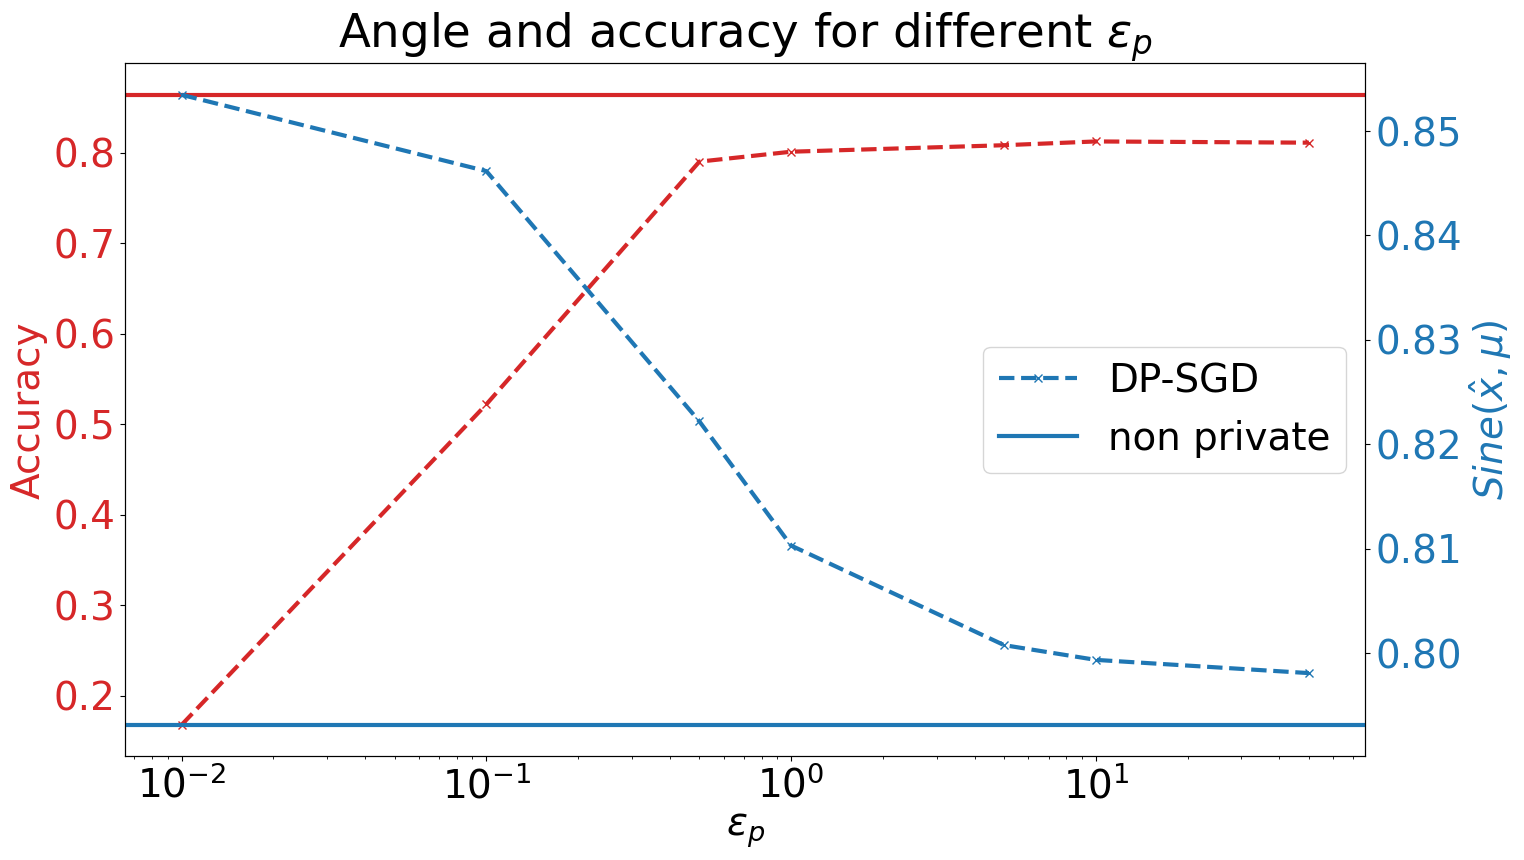

In [38]:
# Plot the results.
plt.rcParams.update({'font.size': 28})
fig, ax1 = plt.subplots()
fig.set_size_inches(16, 9)
color = 'tab:red'
ax1.set_xlabel(r'$\epsilon_p$')
ax1.set_ylabel('Accuracy', color=color)
ax1.semilogx(eps_arr, acc_dpsgd, color=color, linestyle='--', marker='x', linewidth=3, label='DP-SGD')
#ax1.plot(eps_arr, acc_output, color=color, linestyle='-.', marker='o',linewidth=3, label='output')
ax1.axhline(y=non_priv_acc, color=color, linestyle='-',linewidth=3, label='non private')
ax1.tick_params(axis='y', labelcolor=color)
        
ax2 = ax1.twinx()
        
color = 'tab:blue'
ax2.set_ylabel(r'$Sine(\hat{x}, \mu)$', color=color)
ax2.semilogx(eps_arr, angles_dpsgd, color=color, linestyle='--', linewidth=3, marker='x', label='DP-SGD')
#ax2.plot(eps_arr, angles_output, color=color, linestyle='-.', linewidth=3, marker='o', label='output')
ax2.axhline(y=non_priv_angle, color=color, linestyle='-', linewidth=3, label='non private')
ax2.tick_params(axis='y', labelcolor=color)

#fig.tight_layout()

plt.title(fr"Angle and accuracy for different $\epsilon_p$")
plt.legend(loc='center right')
plt.savefig('./dp_sgd.png')

# Experiment for different $n$ and fixed privacy budget $\epsilon$.

Next we evaluate how DP-SGD performs under different training dataset size for a fixed privacy budget.

## Setup

* **epochs**: 3
* **learning rate**: 0.25
* **batch size**: 250
* **number of microbatches**: 250
* **delta**: $10^{-5}$
* **privacy budget** $\epsilon$: 0.1

In [49]:
N = [x for x in range(1000, 60000, 5000)]

acc_n, angles_n, non_priv_acc = [], [], []
for n in N:
    print("Running experiment for n = ", n)

    train_data, train_labels, test_data, test_labels, means = load_dataset(n)

    # Non private metrics
    model_non_priv.fit(train_data, train_labels,
          epochs=epochs,
          validation_data=(test_data, test_labels),
          batch_size=batch_size)
    
    val_acc = 0
    for _ in range(10):
        _, val_tmp = model_non_priv.evaluate(test_data, test_labels, batch_size=batch_size, verbose=0)
        val_acc += val_tmp
    non_priv_acc.append(val_acc/10)
    
    
    iters = 10
    acc, angle = 0, 0
    for _ in range(iters):
        acc_tmp, angle_tmp = perform_experiment(0.1)
        acc += acc_tmp
        angle += angle_tmp
    acc_n.append(acc/iters)
    angles_n.append(angle_tmp/iters)




Running experiment for n =  1000
Epoch 1/3
4/4 [==============================] - 0s 73ms/step - loss: 5.7510 - accuracy: 0.9130 - val_loss: 6.2552 - val_accuracy: 0.9148
Epoch 2/3
4/4 [==============================] - 0s 34ms/step - loss: 4.2086 - accuracy: 0.9320 - val_loss: 6.3716 - val_accuracy: 0.9140
Epoch 3/3
4/4 [==============================] - 0s 35ms/step - loss: 4.0645 - accuracy: 0.9240 - val_loss: 6.3954 - val_accuracy: 0.9092
Performing experiment for epsilon = 0.1
Epoch 1/3
4/4 [==============================] - 1s 98ms/step - loss: 2.3314 - accuracy: 0.1350 - val_loss: 2.4547 - val_accuracy: 0.1183
Epoch 2/3
4/4 [==============================] - 0s 51ms/step - loss: 2.5306 - accuracy: 0.1400 - val_loss: 2.6753 - val_accuracy: 0.1371
Epoch 3/3
4/4 [==============================] - 0s 57ms/step - loss: 2.5617 - accuracy: 0.1600 - val_loss: 2.6263 - val_accuracy: 0.1448
Performing experiment for epsilon = 0.1
Epoch 1/3
4/4 [==============================] - 1s 94ms/st

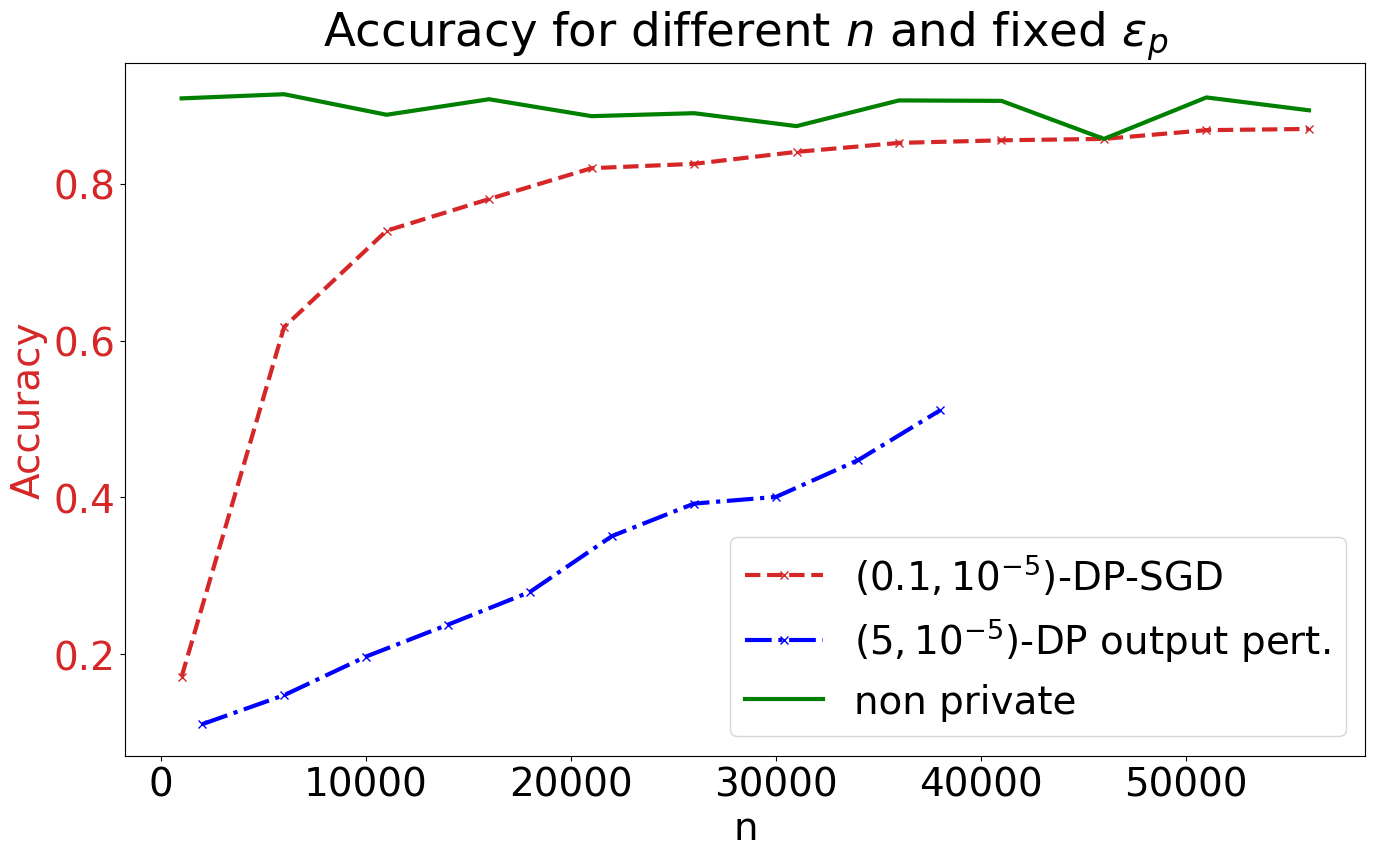

In [73]:
np.save('dpsgd_acc_n_n2000', acc_n)


gaussian_n = np.load('./data/acc_output_n_gaussian.npy')
gaussian_arr_n = np.load('./data/n_arr_gaussian.npy')

plt.rcParams.update({'font.size': 28})
fig, ax1 = plt.subplots()
fig.set_size_inches(16, 9)
color = 'tab:red'
ax1.set_xlabel('n')
ax1.set_ylabel('Accuracy', color=color)
ax1.plot(N, acc_n, color=color, linestyle='--', marker='x', linewidth=3, label='$(0.1, 10^{{-5}})$-DP-SGD')
ax1.plot(gaussian_arr_n, gaussian_n, color='blue', linestyle='-.', marker='x', linewidth=3, label=fr"$(5, 10^{{-5}})$-DP output pert.")
#ax1.plot(N, acc_output, color=color, linestyle='-.', marker='o',linewidth=3, label='output')
ax1.plot(N, non_priv_acc, color='green', linestyle='-',linewidth=3, label='non private')
ax1.tick_params(axis='y', labelcolor=color)
plt.title(fr"Accuracy for different $n$ and fixed $\epsilon_p$")
plt.legend(loc='lower right')
plt.savefig('./data/acc_n_dp_sgd_T3')